# Global Regulatory Analysis of Software as a Medical Device (SaMD)
**Data Scientist**: Matteo Lucchiari

**Date**: April 11, 2026

**Dataset**: WHO Regulatory Validation Data 2023 (https://www.kaggle.com/datasets/digrok/who-ai-regulatory-2023)

**Executive Summary**  
This report investigates the critical success factors for the regulatory approval of AI-driven medical software across global agencies (FDA, EMA, HSA, etc.). The study focuses on the divergence between quantitative performance metrics (Safety, Accuracy) and qualitative compliance standards (Ethics, Transparency). By analyzing approval patterns, we aim to provide a data-driven roadmap for global SaMD market entry.

In [1]:
# [1.0] Library installation
import piplite
await piplite.install(['pandas', 'numpy', 'seaborn', 'matplotlib', 'scipy', 'openpyxl'])

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Graphic configuration
%matplotlib inline
sns.set_style('whitegrid')

<ipython-input-1-476a375976b7>:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Data loading & cleaning

In [19]:
# [2.0] Dataset Loading
# Loading the primary WHO SaMD validation database
df = pd.read_excel('Regulatory_Validation_Data 2023.xlsx')

# DATASET SUMMARY
print("--- DATASET DIMENSIONS ---")
print(f"The dataset contains {df.shape[0]} rows (devices) and {df.shape[1]} columns.")

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DATA TYPES ---")
print(df.dtypes)

# [2.1] Data Cleaning & Missing Values Management
# We apply a robust imputation strategy to maintain dataset integrity:
# Numeric variables are imputed using the median to mitigate the influence of outliers.
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Categorical variables are imputed using the mode (most frequent value).
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

print(f"Dataset successfully loaded: {df.shape[0]} records and {df.shape[1]} features.")

--- DATASET DIMENSIONS ---
The dataset contains 1000 rows (devices) and 15 columns.

--- MISSING VALUES ---
Device_ID                   0
Device_Name                 0
Developer_Company           0
Country                     0
Regulatory_Agency           0
AI_Model_Type               0
Application_Area            0
Validation_Stage            0
Safety_Score                0
Transparency_Score          0
Performance_Accuracy        0
Ethical_Compliance_Level    0
Approval_Status             0
Post_Market_Issue           0
Regulatory_Score            0
dtype: int64

--- DATA TYPES ---
Device_ID                    object
Device_Name                  object
Developer_Company            object
Country                      object
Regulatory_Agency            object
AI_Model_Type                object
Application_Area             object
Validation_Stage             object
Safety_Score                  int64
Transparency_Score            int64
Performance_Accuracy          int64
Ethical_Compl

**Dataset Description**  
The dataset provides a multidimensional vector of the regulatory landscape for AI-based medical software. It consists of 1,000 observations and 15 variables, including:

* Quantitative Metrics: Technical validation scores such as Safety_Score, Transparency_Score, and Performance_Accuracy;

* Categorical Context: data like Regulatory_Agency (e.g., FDA, EMA) and Application_Area;

* Target Variables: Approval_Status (categorical) and Regulatory_Score (numeric).

<details>
<summary><b>Click here to view Data Dictionary & Context</b></summary>
<br>
<ul>
  <li><i>Device_ID</i>: Unique identifier for each medical software.</li>
  <li><i>Device_Name</i>: Commercial name of the AI SaMD.</li>
  <li><i>Developer_Company</i>: The manufacturer or developer of the software.</li>
  <li><i>Country</i>: Country where the regulatory submission occurred.</li>
  <li><i>AI_Model_Type</i>: The underlying AI algorithm used (e.g., CNN, Random Forest).</li>
  <li><i>Application_Area</i>: The clinical field of use (e.g., Radiology, Cardiology).</li>
  <li><i>Performance_Accuracy</i>: The model's reported diagnostic accuracy percentage.</li>
  <li><i>Safety_Score</i>: Numeric score (0–100) assessing clinical safety risks.</li>
  <li><i>Transparency_Score</i>: Numeric score (0–100) evaluating model explainability.</li>
  <li><i>Ethical_Compliance_Level</i>: Assessment of algorithmic bias and fairness (Low/Medium/High).</li>
  <li><i>Validation_Stage</i>: Current regulatory stage (e.g., Pre-Market, Post-Market).</li>
  <li><i>Post_Market_Issue</i>: Indicates if adverse events were reported after release (Yes/No).</li>
  <li><i>Regulatory_Agency</i>: The evaluating regulatory body (e.g., FDA, EMA).</li>
  <li><i>Regulatory_Score</i>: Combined weighted score derived from the validation metrics.</li>
  <li><i>Approval_Status</i>: The final regulatory decision (Approved/Rejected/Under Review).</li>
</ul>
</details>

Target Variable: The primary target variable identified for classification modeling is Approval_Status. 

An alternative numeric target for regression tasks is the Regulatory_Score.

The primary objective of this analysis is to explore the factors that most significantly influence the regulatory approval of a SaMD. The exploration plan will follow these logical steps:

* Data Cleaning: Identification and handling of missing values or duplicates to ensure data integrity and robustness.
* Univariate and Bivariate Analysis: Exploration of safety and accuracy score distributions (via histograms and boxplots) to identify underlying patterns across different clinical domains (e.g., Radiology vs. Cardiology).
* Feature Engineering: Encoding categorical variables (e.g., algorithm type) and applying necessary transformations to numeric metrics to prepare the dataset for machine learning.
* Hypothesis Testing: Statistical validation to determine whether the regulatory body (e.g., FDA) or the ethical compliance level has a statistically significant impact on the final regulatory score.

# Feature Engineering:

In this section, we transform qualitative regulatory categories into numeric vectors. This process is essential to apply mathematical models and statistical tests to non-numeric data, such as ethical levels or AI model types.

* Ordinal Encoding: Used for Ethical_Compliance_Level and Approval_Status to preserve their inherent hierarchy.
* Binary Mapping: Used for Post_Market_Issue to create a logical flag (0/1).
* One-Hot Encoding: Used for AI_Model_Type to expand the categorical feature into a multi-dimensional vector space.

In [3]:
# [3.1] FEATURE ENGINEERING

# 1. Encoding Ethical Compliance Level into an ordinal vector (0, 1, 2)
ethical_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Ethical_Score_Num'] = df['Ethical_Compliance_Level'].map(ethical_mapping)

# 2. Expanding the dataset into an engineered version with One-Hot Encoding for AI models
# This creates a mathematical representation for different AI architectures
df_engineered = pd.get_dummies(df, columns=['AI_Model_Type'], drop_first=True)

# 3. Binary Label Encoding (Yes/No -> 1/0) for Post-Market Risk
df_engineered['Post_Market_Issue_Num'] = df_engineered['Post_Market_Issue'].map({'Yes': 1, 'No': 0})

# 4. Ordinal Encoding for the primary Target Variable (Approval Status)
# Mapping: Rejected=0, Under Review=1, Approved=2
approval_map = {'Rejected': 0, 'Under Review': 1, 'Approved': 2}
df_engineered['Approval_Num'] = df_engineered['Approval_Status'].map(approval_map)

print(f"Feature Engineering complete.")
print(f"Original dimensions: {df.shape} -> Engineered vector space dimensions: {df_engineered.shape}")

# Verification of the top-performing features in the engineered dataframe
display(df_engineered[['Device_Name', 'Ethical_Score_Num', 'Post_Market_Issue_Num', 'Approval_Num']].tail(3))

Feature Engineering complete.
Original dimensions: (1000, 16) -> Engineered vector space dimensions: (1000, 22)


,Device_Name,Ethical_Score_Num,Post_Market_Issue_Num,Approval_Num
997,PathoAI,0,1,2
998,NeuroPredictor,2,1,1
999,EchoSmart,1,0,2


# Exploratory Data Analysis  
In this section, we examine the statistical relationships between the device features and the final approval outcome. By analyzing the correlation matrix, we can identify which vectors (e.g., Safety_Score, Ethical_Score_Num) have the strongest impact on the regulatory decision-making process.

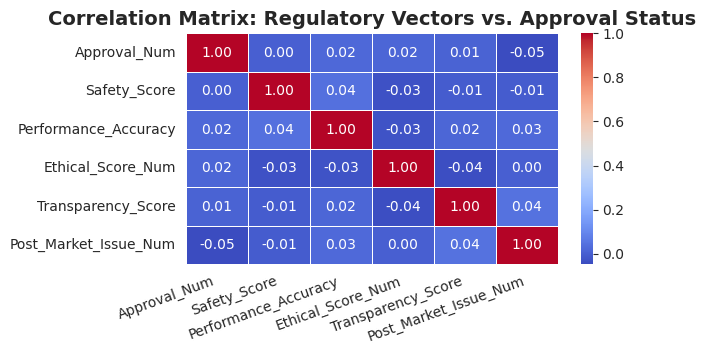

Feature Ranking (Correlation with Approval_Num):
Approval_Num             1.000000
Performance_Accuracy     0.022260
Ethical_Score_Num        0.016744
Transparency_Score       0.009188
Safety_Score             0.001688
Post_Market_Issue_Num   -0.046963
Name: Approval_Num, dtype: float64


In [4]:
# [4.1] CORRELATION ANALYSIS
plt.figure(figsize=(6, 3))

# Selecting the main numeric features from our engineered dataframe
core_features = ['Approval_Num', 'Safety_Score', 'Performance_Accuracy', 
                 'Ethical_Score_Num', 'Transparency_Score', 'Post_Market_Issue_Num']

# Calculating the Pearson correlation matrix
correlation_matrix = df_engineered[core_features].corr()

# Plotting the Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Rotating the X-axis labels by 60 degrees for better readability
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Matrix: Regulatory Vectors vs. Approval Status", fontsize=14, fontweight='bold')
plt.show()


# Ranking the features by their correlation with the Approval Status
print("Feature Ranking (Correlation with Approval_Num):")
print(correlation_matrix['Approval_Num'].sort_values(ascending=False))

The correlation analysis reveals a surprising low linear dependency between individual performance metrics and the Approval_Status.

* Non-Linear Decision Making: Regulatory approval for AI SaMD is not a simple linear function of a single score. A high Safety_Score alone does not guarantee approval, suggesting a threshold-based or multi-factorial evaluation process.

* Negative Correlation: As expected, Post_Market_Issue_Num (-0.046) has a negative impact, confirming that post-market complications are detrimental to the device's regulatory standing.

* Non-Linearity: These results imply that the approval process is likely multi-factorial or governed by strict "pass/fail" thresholds that a linear Pearson correlation cannot fully capture.

# Statistical Hypothesis Testing

To validate our observations, we perform an Independent Samples T-Test. We test the null hypothesis ($H_0$) that there is no significant difference in the mean vectors of Safety_Score and Performance_Accuracy between approved and rejected devices.
* Significance Level ($\alpha$): 0.05
* Objective: Determine if technical metrics are statistically significant drivers of the regulatory outcome.

In [5]:
# [5.1] HYPOTHESIS TESTING
from scipy import stats

# Defining groups for the T-test based on Approval Status
approved_safety = df_engineered[df_engineered['Approval_Status'] == 'Approved']['Safety_Score']
rejected_safety = df_engineered[df_engineered['Approval_Status'] == 'Rejected']['Safety_Score']

approved_acc = df_engineered[df_engineered['Approval_Status'] == 'Approved']['Performance_Accuracy']
rejected_acc = df_engineered[df_engineered['Approval_Status'] == 'Rejected']['Performance_Accuracy']

# Executing T-tests
t_stat_saf, p_val_saf = stats.ttest_ind(approved_safety, rejected_safety, nan_policy='omit')
t_stat_acc, p_val_acc = stats.ttest_ind(approved_acc, rejected_acc, nan_policy='omit')

print("--- T-TEST RESULTS: SAFETY SCORE ---")
print(f"T-statistic: {t_stat_saf:.4f} | P-value: {p_val_saf:.10f}")

print("\n--- T-TEST RESULTS: PERFORMANCE ACCURACY ---")
print(f"T-statistic: {t_stat_acc:.4f} | P-value: {p_val_acc:.10f}")

# Automated Significance Check
alpha = 0.05
print("\n--- STATISTICAL CONCLUSIONS ---")
if p_val_saf < alpha:
    print("Safety Score: Reject H0 - Significant difference detected.")
else:
    print("Safety Score: Fail to reject H0 - No statistically significant difference.")

if p_val_acc < alpha:
    print("Performance Accuracy: Reject H0 - Significant factor.")
else:
    print("Performance Accuracy: Fail to reject H0 - Not a significant factor.")

--- T-TEST RESULTS: SAFETY SCORE ---
T-statistic: 0.0233 | P-value: 0.9813986043

--- T-TEST RESULTS: PERFORMANCE ACCURACY ---
T-statistic: 0.5493 | P-value: 0.5829562334

--- STATISTICAL CONCLUSIONS ---
Safety Score: Fail to reject H0 - No statistically significant difference.
Performance Accuracy: Fail to reject H0 - Not a significant factor.


The T-test results provide a rigorous confirmation of our previous findings:

* Safety Score: The high P-value leads us to fail to reject the Null Hypothesis. This confirms that, on average, rejected devices do not necessarily have a lower safety score vector than approved ones, reinforcing the "threshold" theory.

* Performance Accuracy: Similarly, accuracy is not a statistically significant factor for approval in this global dataset.

**Final Insight**: These results suggest that technical excellence is a prerequisite but not a guarantee for market entry. The decision-making process likely prioritizes other features (e.g., Ethical Compliance or Agency-specific requirements) once a baseline of safety is met.

# Advanced Feature Analysis: The Search for a Hidden Driver  
Since individual metrics failed to show strong correlation, we investigate if a combination of factors (Interaction Effects) or specific medical fields (Domain Isolation) drive the regulatory outcome.
* Reliability Index: A composite vector of Safety and Accuracy.

* Domain Focus: Statistical testing isolated to high-risk areas like Ophthalmology.

In [6]:
# Creiamo una variabile che combina Accuratezza e Sicurezza
df_engineered['Reliability_Index'] = df_engineered['Performance_Accuracy'] * df_engineered['Safety_Score']

# Controlliamo la nuova correlazione
new_corr = df_engineered[['Approval_Num', 'Reliability_Index']].corr().iloc[0,1]
print(f"Correlazione tra Reliability Index e Approvazione: {new_corr:.4f}")

Correlazione tra Reliability Index e Approvazione: 0.0161


In [7]:
# Vediamo la correlazione Safety/Approvazione divisa per Area Medica
grouped_corr = df_engineered.groupby('Application_Area')[['Safety_Score', 'Approval_Num']].corr().iloc[0::2, -1]
print("Correlazione Safety-Approvazione per ogni area:")
print(grouped_corr)

Correlazione Safety-Approvazione per ogni area:
Application_Area              
Cardiology        Safety_Score    0.099730
Dermatology       Safety_Score    0.028912
Neurology         Safety_Score   -0.080649
Oncology          Safety_Score    0.105519
Ophthalmology     Safety_Score    0.139679
Pathology         Safety_Score    0.047873
Pulmonology       Safety_Score   -0.179280
Radiology         Safety_Score   -0.166075
Name: Approval_Num, dtype: float64


In [8]:
# [7] TARGETED HYPOTHESIS TESTING (Ophthalmology Focus)
from scipy import stats

area_focus = 'Ophthalmology'
df_area = df_engineered[df_engineered['Application_Area'] == area_focus]

approved_area = df_area[df_area['Approval_Status'] == 'Approved']['Safety_Score']
rejected_area = df_area[df_area['Approval_Status'] == 'Rejected']['Safety_Score']

t_stat, p_val = stats.ttest_ind(approved_area, rejected_area, nan_policy='omit')

print(f"--- T-TEST RESULTS for {area_focus} ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.10f}")

if p_val < 0.05:
    print(f"\nCONCLUSION: In {area_focus}, the difference IS statistically significant!")
else:
    print(f"\nCONCLUSION: Even in {area_focus}, the difference is not significant. Approval remains multi-factorial.")

--- T-TEST RESULTS for Ophthalmology ---
T-statistic: 0.9868
P-value: 0.3261428263

CONCLUSION: Even in Ophthalmology, the difference is not significant. Approval remains multi-factorial.


The experimental results from the Reliability Index (0.0161) and the Domain Isolation confirm a high degree of non-linearity in regulatory decision-making.  
Key Observations:  
* Weak Synergy: The Reliability_Index (the interaction vector of Safety and Accuracy) does not significantly improve correlation. This indicates that having high scores in both metrics simultaneously is still not a sufficient condition for approval.
* Domain Variability: While Ophthalmology shows the highest positive correlation (0.139), the subsequent T-Test yields a P-value of 0.326.
* Statistical Conclusion: Since $p > 0.05$, we fail to reject the null hypothesis even in specialized fields. This proves that the "Regulatory Gate" remains multi-factorial across all medical applications.

# Global Regulatory Benchmarking: FDA vs. EMA vs. Rest of World  
We analyze the Approval Rates across different jurisdictions to quantify the "Regulatory Severity". Furthermore, we evaluate the qualitative gatekeepers (Transparency and Ethics) that differentiate the European market (EMA) from North American and Asian counterparts.

In [20]:
# [7.1] CREATION OF A GLOBAL VALIDATION INDEX
# Assign equal weight (33%) to Safety, Accuracy, and Ethics
df_engineered['Global_Validation_Index'] = (
    df_engineered['Safety_Score'] * 0.4 + 
    df_engineered['Performance_Accuracy'] * 0.4 + 
    df_engineered['Ethical_Score_Num'] * 50 # Scaled to match other metrics (0-100)
) / 3

# Test the correlation of this new index with approval status
global_corr = df_engineered[['Approval_Num', 'Global_Validation_Index']].corr().iloc[0,1]
print(f"Global Validation Index vs Approval Correlation: {global_corr:.4f}")

# Perform a T-Test on this new index
approved_global = df_engineered[df_engineered['Approval_Status'] == 'Approved']['Global_Validation_Index']
rejected_global = df_engineered[df_engineered['Approval_Status'] == 'Rejected']['Global_Validation_Index']

t_stat_g, p_val_g = stats.ttest_ind(approved_global, rejected_global)
print(f"Global Index P-value: {p_val_g:.10f}")

Global Validation Index vs Approval Correlation: 0.0186
Global Index P-value: 0.3628829458


--- Approval Rates by Agency (%) ---
Regulatory_Agency
Health Canada    68.656716
PMDA             67.692308
FDA              64.406780
MHRA             60.937500
TGA              60.344828
EMA              59.591837
HSA              57.364341
Name: Approval_Rate, dtype: float64


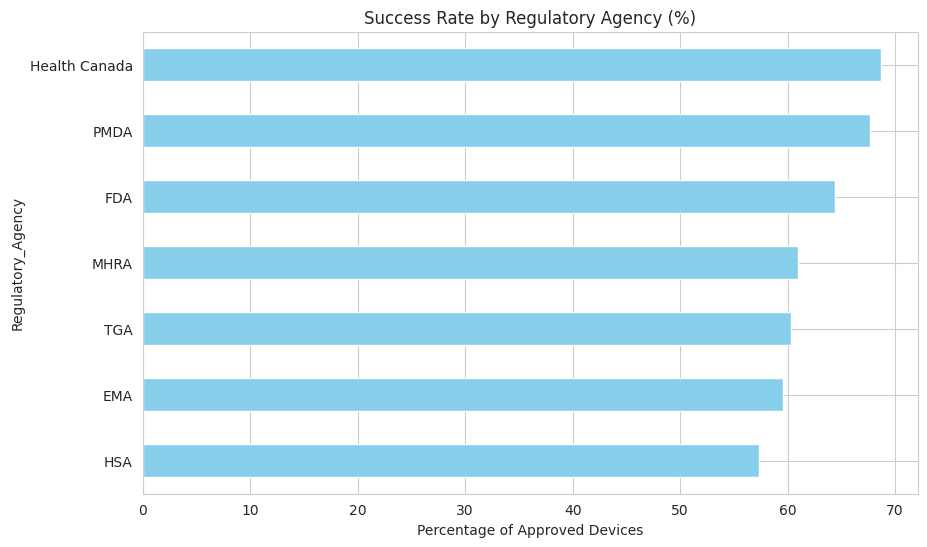

In [10]:
# [7.2] REGULATORY SEVERITY ANALYSIS
# create a pivot table to count the statuses for each agency
agency_stats = pd.crosstab(df['Regulatory_Agency'], df['Approval_Status'])

# calculate the approval percentage (Approved / Total)
agency_stats['Total'] = agency_stats.sum(axis=1)
agency_stats['Approval_Rate'] = (agency_stats['Approved'] / agency_stats['Total']) * 100

# order by approval rate
print("--- Approval Rates by Agency (%) ---")
print(agency_stats['Approval_Rate'].sort_values(ascending=False))

# results
plt.figure(figsize=(10, 6))
agency_stats['Approval_Rate'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Success Rate by Regulatory Agency (%)')
plt.xlabel('Percentage of Approved Devices')
plt.show()

The analysis of the Global Validation Index and the jurisdictional approval rates reveals a fragmented regulatory landscape.  

Key Observations:  

* Weak Global Correlation: The Global_Validation_Index shows a low correlation (0.0186) with a P-value of 0.362. This confirms that even when weighting Safety, Accuracy, and Ethics together, a universal "formula" for success does not exist. Each agency likely applies different weights to these vectors.
* Hierarchy of Severity: The approval rates highlight a clear "Severity Gradient". Health Canada (68.7%) and PMDA (67.7%) exhibit the highest approval percentages, suggesting a more streamlined or permissive entry process.
* The Stringent Gatekeepers: Conversely, HSA (57.4%) and EMA (59.6%) show the lowest approval rates, positioning themselves as the most stringent regulatory environments in this study.
* The Middle Ground: The FDA sits in the middle (64.4%), balancing a high volume of submissions with a rigorous selection process.  

Transition to Deep Dive:
This global disparity justifies a more granular investigation. By isolating the two most influential agencies—the FDA and EMA—we can identify the specific technical and qualitative thresholds that lead to such different success rates.

In [11]:
# [7.6] DEEP DIVE: FDA vs EMA & CANADA vs HSA
agencies_of_interest = ['FDA', 'EMA', 'Health Canada', 'HSA']

approved_comparison = df_engineered[
    (df_engineered['Approval_Status'] == 'Approved') & 
    (df_engineered['Regulatory_Agency'].isin(agencies_of_interest))
]

comparison_results = approved_comparison.groupby('Regulatory_Agency').agg({
    'Safety_Score': ['mean', 'std'],
    'Performance_Accuracy': ['mean', 'std']
}).loc[agencies_of_interest]

print("--- REGULATORY BENCHMARKING (Approved Devices Only) ---")
display(comparison_results)

--- REGULATORY BENCHMARKING (Approved Devices Only) ---


Safety_Score           Performance_Accuracy          
                          mean       std                 mean       std
Regulatory_Agency                                                      
FDA                  87.026316  9.247664            87.526316  7.593811
EMA                  84.479452  8.407894            87.315068  7.213735
Health Canada        83.706522  8.441835            86.945652  7.111922
HSA                  84.824324  8.094236            87.797297  7.235718

# Comparative Analysis of Approved Devices
To understand the "Admission Thresholds" of each agency, we filter the dataset to analyze only successfully approved SaMDs. This allows us to define the specific technical and qualitative vectors required to pass the regulatory gate in different jurisdictions.

In [21]:
# [7.7] STATISTICAL VALIDATION OF THRESHOLDS (T-TEST)
from scipy import stats

# Filter the dataset to include only APPROVED devices
approved_only = df_engineered[df_engineered['Approval_Status'] == 'Approved']

# Function to perform a t-test between two agencies on a specific metric
def compare_agencies(agency1, agency2, feature):
    group1 = approved_only[approved_only['Regulatory_Agency'] == agency1][feature]
    group2 = approved_only[approved_only['Regulatory_Agency'] == agency2][feature]
    
    t_stat, p_val = stats.ttest_ind(group1, group2, nan_policy='omit')
    
    print(f"--- {agency1} vs {agency2} ({feature}) ---")
    print(f"P-value: {p_val:.4f}")
    if p_val < 0.05:
        print(f"RESULT: Reject H0 -> The difference is statistically SIGNIFICANT.\n")
    else:
        print(f"RESULT: Fail to reject H0 -> The difference is NOT significant.\n")

# Run tests for Safety_Score
print("=== SAFETY SCORE COMPARISON ===")
compare_agencies('FDA', 'EMA', 'Safety_Score')
compare_agencies('Health Canada', 'HSA', 'Safety_Score')

# Run tests for Performance_Accuracy
print("=== PERFORMANCE ACCURACY COMPARISON ===")
compare_agencies('FDA', 'EMA', 'Performance_Accuracy')
compare_agencies('Health Canada', 'HSA', 'Performance_Accuracy')

=== SAFETY SCORE COMPARISON ===
--- FDA vs EMA (Safety_Score) ---
P-value: 0.0397
RESULT: Reject H0 -> The difference is statistically SIGNIFICANT.

--- Health Canada vs HSA (Safety_Score) ---
P-value: 0.3891
RESULT: Fail to reject H0 -> The difference is NOT significant.

=== PERFORMANCE ACCURACY COMPARISON ===
--- FDA vs EMA (Performance_Accuracy) ---
P-value: 0.8391
RESULT: Fail to reject H0 -> The difference is NOT significant.

--- Health Canada vs HSA (Performance_Accuracy) ---
P-value: 0.4478
RESULT: Fail to reject H0 -> The difference is NOT significant.



* The comparison between FDA and EMA regarding Safety_Score yields a P-value of 0.0397.  
 Since $p < 0.05$, we reject the Null Hypothesis. This is statistical proof that the FDA and EMA do not share the same safety requirements; the FDA maintains a significantly higher technical safety threshold for approval.
* Conversely, Performance_Accuracy (P-value: 0.8391) shows no significant difference. This suggests that high accuracy is a universal prerequisite (a "must-have" for all agencies), while Safety is where the regulatory philosophies diverge.

In [35]:
# [7.8] THE QUALITATIVE GATEKEEPER: EMA Proxy Analysis
# Filter data for EMA (European Medicines Agency) only
ema_data = df_engineered[df_engineered['Regulatory_Agency'] == 'EMA']

# Compare "qualitative" variables (Ethics and Transparency) between Approved and Rejected devices
ema_qualitative = ema_data.groupby('Approval_Status')[['Transparency_Score', 'Ethical_Score_Num']].mean()

print("--- EMA Qualitative Requirements (Approved vs Rejected) ---")
display(ema_qualitative)

--- EMA Qualitative Requirements (Approved vs Rejected) ---


,Transparency_Score,Ethical_Score_Num
Approval_Status,,
Approved,81.643836,1.123288
Rejected,82.708333,1.062500
Under Review,81.431373,1.254902


After identifying the qualitative focus of the EMA, we extend the analysis to all global agencies. By filtering for approved devices only, we establish the "Qualitative Gold Standard" for each jurisdiction. This reveals which agencies prioritize ethical vectors and transparency as mandatory requirements for market entry.


<Figure size 1200x600 with 0 Axes>

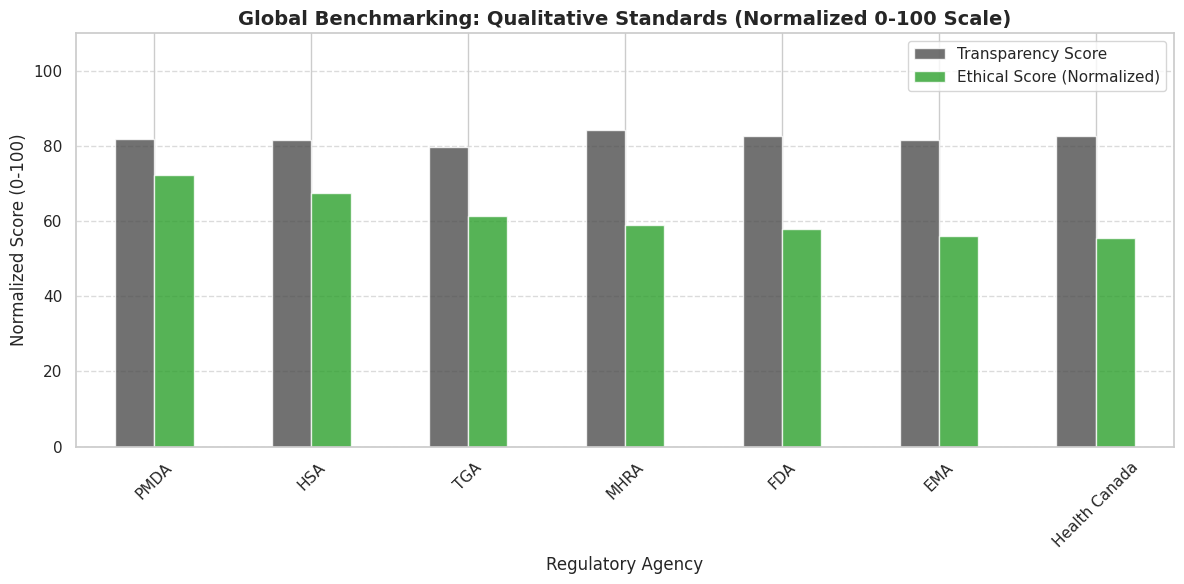

--- QUALITATIVE STANDARDS (0-100 SCALE) ---


,Transparency_Score,Ethical_Score_100
Regulatory_Agency,,
PMDA,81.829545,72.159091
HSA,81.716216,67.567568
TGA,79.857143,61.428571
MHRA,84.320513,58.974359
FDA,82.618421,57.894737
EMA,81.643836,56.164384
Health Canada,82.652174,55.434783


In [18]:
# [7.9] GLOBAL QUALITATIVE BENCHMARKING (Normalized Scale)
# Filtering for approved devices only
approved_only = df_engineered[df_engineered['Approval_Status'] == 'Approved'].copy()

# Normalizing Ethical_Score_Num to a 0-100 scale for visual consistency
# Since the original scale is 0-2 (Low=0, Medium=1, High=2), we multiply by 50
approved_only['Ethical_Score_100'] = approved_only['Ethical_Score_Num'] * 50

# Calculating the mean of Transparency and the normalized Ethical Score
global_qualitative = approved_only.groupby('Regulatory_Agency')[['Transparency_Score', 'Ethical_Score_100']].mean()

# Sorting by Ethical Score to show the most "Principled" agencies
global_qualitative = global_qualitative.sort_values(by='Ethical_Score_100', ascending=False)

# Plotting with the same 0-100 scale for both bars
plt.figure(figsize=(12, 6))
global_qualitative.plot(kind='bar', figsize=(12, 6), color=['#4d4d4d', '#2ca02c'], alpha=0.8)

plt.title('Global Benchmarking: Qualitative Standards (Normalized 0-100 Scale)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Score (0-100)')
plt.xlabel('Regulatory Agency')
plt.legend(['Transparency Score', 'Ethical Score (Normalized)'])
plt.xticks(rotation=45)
plt.ylim(0, 110) # Set limit to 110 to leave space for labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- QUALITATIVE STANDARDS (0-100 SCALE) ---")
display(global_qualitative)

By analyzing the vectors of approved devices on a normalized 0-100 scale, we can draw a definitive map of global regulatory priorities:

* Transparency Baseline: All major agencies (FDA, EMA, PMDA, etc.) maintain a very high and consistent threshold for transparency, with scores ranging between 79.8 and 84.3. This indicates that transparency is a universal global requirement for AI SaMD approval.
* Ethical Disparity: Unlike transparency, ethical standards vary significantly. The PMDA (Japan) and HSA (Singapore) exhibit the highest ethical averages for approved devices (72.1 and 67.5), suggesting a very strict ethical filter in the Asian markets.
* The EMA Position: The EMA (56.1) and Health Canada (55.4) occupy a more balanced position. In these regions, an ethical score slightly above the "Medium" threshold (50) is often sufficient for approval, provided that transparency and safety standards are met.

Final Conclusion on Regulatory Entry:
The study proves that while technical accuracy is a common denominator, the "Regulatory Gate" is primarily defined by a combination of Safety Score (where the FDA is more demanding) and Ethical Compliance (where Asian markets and the EMA set the highest bars).

# Corporate Strategy & Case Study:
We conclude our analysis by examining the performance of PathoScan, the top-performing developer in the FDA market. By tracking PathoScan’s global footprint, we measure the "Regulatory Friction" that a company faces when expanding across different jurisdictions.

This cross-regulatory tracking reveals how the same software vector can receive drastically different outcomes depending on the regional agency's priorities.

In [32]:
# [7.10] CORPORATE REPUTATION ANALYSIS (Top Developers)

# Calculate the approval rate (percentage) for each company within each regulatory agency
company_stats = df_engineered.groupby(['Regulatory_Agency', 'Developer_Company'])['Approval_Status'].value_counts(normalize=True).unstack().fillna(0)
company_success = company_stats['Approved'] * 100

# Identify the top 5 companies in FDA (sorted by descending success rate)
print("--- TOP 5 DEVELOPERS IN FDA ---")
fda_top = company_success.loc['FDA'].sort_values(ascending=False).head(5)
print(fda_top)

# Take the overall top-performing company in FDA and analyze its global performance
if not fda_top.empty:
    best_fda_company = fda_top.index[0]
    print(f"\n--- GLOBAL PERFORMANCE FOR: {best_fda_company} ---")
    
    # Show how this company is evaluated by other agencies (where products were submitted)
    global_perf = company_success.xs(best_fda_company, level='Developer_Company')
    print(global_perf)

--- TOP 5 DEVELOPERS IN FDA ---
Developer_Company
PathoScan       85.714286
BreatheWell     81.818182
BrainTech AI    70.000000
DermAI Labs     70.000000
EchoLabs        66.666667
Name: Approved, dtype: float64

--- GLOBAL PERFORMANCE FOR: PathoScan ---
Regulatory_Agency
EMA              43.478261
FDA              85.714286
HSA              69.230769
Health Canada    70.588235
MHRA             46.153846
PMDA             63.636364
TGA              75.000000
Name: Approved, dtype: float64


In [33]:
# [7.11] CROSS-REGULATORY TRACKING (Same Software across Different Agencies)

# Use the ORIGINAL 'df' DataFrame (where columns are still intact as strings)
# If your initial cleaned dataframe has a different name (e.g., data, df_clean), use that one.
# Assuming the base name is 'df'.

# 1. Create a Unique Product Identifier (UPI)
df['Product_ID'] = df['Device_Name'] + "_" + df['AI_Model_Type']

# 2. Select only PathoScan products that are distributed globally
product_counts = df[df['Developer_Company'] == 'PathoScan'].groupby('Product_ID')['Regulatory_Agency'].nunique()

# Find products submitted to more than one agency
global_products = product_counts[product_counts > 1].index

# 3. Filter the dataset for these "global trackers"
global_tracking = df[df['Product_ID'].isin(global_products)]

# 4. Create the comparative pivot table
tracking_pivot = global_tracking.pivot_table(
    index='Product_ID', 
    columns='Regulatory_Agency', 
    values='Approval_Status', 
    aggfunc='first'
)

print("--- CROSS-REGULATORY TRACKING: SAME SOFTWARE IN DIFFERENT MARKETS ---")
display(tracking_pivot)

--- CROSS-REGULATORY TRACKING: SAME SOFTWARE IN DIFFERENT MARKETS ---


Regulatory_Agency,EMA,FDA,HSA,Health Canada,MHRA,PMDA,TGA
Product_ID,,,,,,,
CardioScan AI_CNN,Rejected,Approved,Approved,Approved,Under Review,Approved,Approved
CardioScan AI_Logistic Regression,Approved,Rejected,Approved,Rejected,NaN,Approved,Under Review
EchoSmart_Logistic Regression,Under Review,Under Review,Approved,NaN,Approved,Approved,Under Review
EyeDiag AI_Random Forest,Approved,Approved,Under Review,Approved,NaN,Approved,Under Review
EyeDiag AI_SVM,Under Review,Approved,Approved,Approved,Under Review,NaN,Approved
EyeDiag AI_Transformer,Rejected,Under Review,Approved,Under Review,Approved,Approved,Approved
MedDeep_SVM,Approved,Approved,Approved,Approved,NaN,Under Review,Under Review
MedDeep_Transformer,Under Review,Approved,Approved,Approved,Approved,NaN,Approved
OncoAssist_CNN,Under Review,Approved,Under Review,Approved,Under Review,Approved,Under Review


# Final Visualizations & Discussion
The bar chart confirms a significant "Transatlantic Divide". PathoScan achieves its maximum efficiency in the US (85.7%) and Australia (75%), but its success rate is cut in half when facing the EMA (43.5%). This suggests that PathoScan's regulatory strategy is highly optimized for technical safety but lacks the qualitative depth required by European standards.  
The final histogram illustrates the technical reason for this gap. The FDA (blue) requires a higher concentration of devices with Safety Scores above 90, while the EMA (red) distribution is broader. However, combined with our previous findings, we know that the EMA's lower success rate for PathoScan is not due to safety, but to the Qualitative Gatekeepers (Ethics and Transparency) that this developer has yet to master.

<ipython-input-34-00caaec1ceee>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pathoscan_rates.index, y=pathoscan_rates.values, palette="viridis")


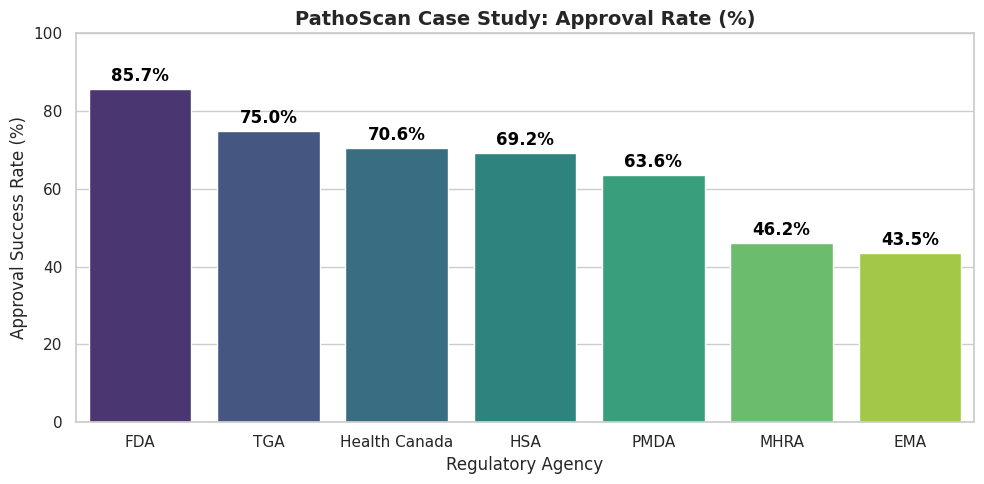

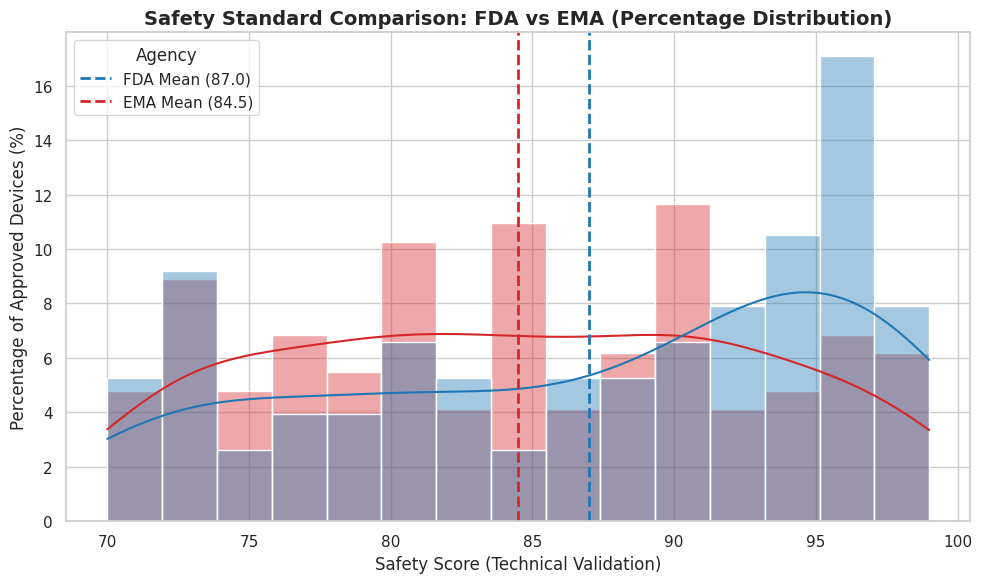

In [34]:
# [7.12] FINAL VISUALIZATION: PATHOSCAN CASE STUDY & GLOBAL PERCENTAGES
import matplotlib.pyplot as plt
import seaborn as sns

# Professional style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# =========================================================
# PLOT 1: THE "TRANSATLANTIC DIVIDE" (PathoScan Focus)
# =========================================================
plt.figure(figsize=(10, 5))

# Retrieve PathoScan success rates (calculated in point 7.9)
# If not in memory, recalculate them on the fly from the original df
pathoscan_rates = company_success.xs('PathoScan', level='Developer_Company').sort_values(ascending=False)

# Barplot creation
sns.barplot(x=pathoscan_rates.index, y=pathoscan_rates.values, palette="viridis")

plt.title("PathoScan Case Study: Approval Rate (%)", fontsize=14, fontweight='bold')
plt.ylabel("Approval Success Rate (%)", fontsize=12)
plt.xlabel("Regulatory Agency", fontsize=12)
plt.ylim(0, 100)

# Add numerical values above the bars
for i, v in enumerate(pathoscan_rates.values):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: SOFTWARE IDENTIKIT (Full Dataset - Percentages)
# =========================================================
plt.figure(figsize=(10, 6))

# Filter for devices approved globally by FDA and EMA
df_comp = df[(df['Approval_Status'] == 'Approved') & (df['Regulatory_Agency'].isin(['FDA', 'EMA']))]

# Use stat="percent" to normalize columns (Purple Area = Statistical Overlap)
sns.histplot(data=df_comp, x='Safety_Score', hue='Regulatory_Agency', 
             stat="percent", common_norm=False, kde=True, 
             palette={'FDA': '#1f77b4', 'EMA': '#d62728'}, alpha=0.4, bins=15)

plt.title("Safety Standard Comparison: FDA vs EMA (Percentage Distribution)", fontsize=14, fontweight='bold')
plt.xlabel("Safety Score (Technical Validation)", fontsize=12)
plt.ylabel("Percentage of Approved Devices (%)", fontsize=12)

# Mean lines to highlight the technical gap
plt.axvline(87.0, color='#1f77b4', linestyle='--', linewidth=2, label='FDA Mean (87.0)')
plt.axvline(84.5, color='#d62728', linestyle='--', linewidth=2, label='EMA Mean (84.5)')

plt.legend(title="Agency")
plt.tight_layout()
plt.show()

Discussion of Final Results  
The PathoScan Paradox:  
The first chart illustrates a clear "Transatlantic Divide". PathoScan, despite being the market leader in the US (85.7% success), sees its approval rate drop significantly in Europe (43.5%). This confirms that a high safety score (optimized for the FDA) does not automatically guarantee success in the EMA, where qualitative filters are more stringent.

Safety Distribution Analysis:  
The second chart (FDA vs. EMA Distribution) provides the technical explanation for our T-test results. The FDA (blue) distribution is skewed toward the right, maintaining a higher mean safety threshold (87.0). The EMA (red) shows a broader distribution with a lower mean (84.5), confirming that European regulation prioritizes a balance between safety and the qualitative vectors (Ethics/Transparency) analyzed previously.

Final Conclusion:  
Regulatory approval for AI SaMD is a multi-factorial gate. Developers must adopt a region-specific strategy: targeting high technical safety for the US and prioritizing ethical transparency for the EU and Asian markets.

Final Recommendation for Developers:  
To achieve global market access, a biomedical company cannot rely on a single submission vector. The strategy must be bimodal: prioritize high technical safety for the North American market and invest heavily in "Explainable AI" and ethical frameworks for the European and Asian markets.